# Deep Neural Network to estimate the pIC50 of BTK molecular glue design

In [1]:
from pathlib import Path
from warnings import filterwarnings

# Silence some expected warnings
filterwarnings("ignore")

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import MACCSkeys, Draw, rdFingerprintGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

# Neural network specific libraries
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint

from rdkit.Chem import PandasTools

%matplotlib inline

2025-05-27 19:15:10.842998: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from rdkit.Chem import PandasTools

# Data directory
DATA = Path("data")

# Data directory
df = PandasTools.LoadSDF(DATA / "gcjeevanb_gmail.com1348_2D.sdf")
df.head()

[19:15:20] Explicit valence for atom # 10 N, 4, is greater than permitted
[19:15:20] ERROR: Could not sanitize molecule ending on line 376141
[19:15:20] ERROR: Explicit valence for atom # 10 N, 4, is greater than permitted
[19:15:20] Explicit valence for atom # 8 N, 4, is greater than permitted
[19:15:20] ERROR: Could not sanitize molecule ending on line 419866
[19:15:20] ERROR: Explicit valence for atom # 8 N, 4, is greater than permitted
[19:15:21] Explicit valence for atom # 8 N, 4, is greater than permitted
[19:15:21] ERROR: Could not sanitize molecule ending on line 838717
[19:15:21] ERROR: Explicit valence for atom # 8 N, 4, is greater than permitted
[19:15:22] Explicit valence for atom # 1 N, 4, is greater than permitted
[19:15:22] ERROR: Could not sanitize molecule ending on line 1309529
[19:15:22] ERROR: Explicit valence for atom # 1 N, 4, is greater than permitted
[19:15:22] Explicit valence for atom # 1 N, 4, is greater than permitted
[19:15:22] ERROR: Could not sanitize mol

,From,BindingDB Reactant_set_id,Ligand InChI,Ligand InChI Key,BindingDB MonomerID,BindingDB Ligand Name,Target Name,Target Source Organism According to Curator or DataSource,Ki (nM),IC50 (nM),...,UniProt (SwissProt) Alternative ID(s) of Target Chain,UniProt (TrEMBL) Submitted Name of Target Chain,UniProt (TrEMBL) Entry Name of Target Chain,UniProt (TrEMBL) Primary ID of Target Chain,UniProt (TrEMBL) Secondary ID(s) of Target Chain,UniProt (TrEMBL) Alternative ID(s) of Target Chain,ID,ROMol,PubChem CID,PubChem SID
0,www.bindingDB.org,456549,InChI=1S/C25H23FN6O2/c1-2-21(33)31-13-3-4-18(1...,ILYWXMXJQALBEV-GOSISDBHSA-N,76963,"US9694011, Example 1 (Compound 17)",Tyrosine-protein kinase BTK,Homo sapiens,,,...,,,,,,,00030001.cdx,<rdkit.Chem.rdchem.Mol object at 0x7aef278c73c0>,NaN,NaN
1,www.bindingDB.org,456550,InChI=1S/C25H23ClN6O2/c1-2-21(33)31-12-6-7-17(...,BCVUHZCEHINVMQ-QGZVFWFLSA-N,76973,"US9694011, Example 2 (Compound 18)",Tyrosine-protein kinase BTK,Homo sapiens,,,...,,,,,,,00031001.cdx,<rdkit.Chem.rdchem.Mol object at 0x7aef278c77b0>,NaN,NaN
2,www.bindingDB.org,508430,InChI=1S/C24H24N6O2/c25-22-21-20(29-23(30(21)1...,KIPHXMLKWLSPCH-SAABIXHNSA-N,267471,N-(pyridin-2-yl)-6-(tributylstannyl)nicotinami...,Tyrosine-protein kinase BTK,Homo sapiens,,,...,,,,,,,00127001.cdx,<rdkit.Chem.rdchem.Mol object at 0x7aef278c7820>,NaN,NaN
3,www.bindingDB.org,508431,"InChI=1S/C25H23F3N6O2/c26-25(27,28)17-9-10-30-...",HGHOIWDVMFUEIR-RZDIXWSQSA-N,267472,4-(8-amino-3-((trans)-4-hydroxycyclohexyl)imid...,Tyrosine-protein kinase BTK,Homo sapiens,,,...,,,,,,,00128001.cdx,<rdkit.Chem.rdchem.Mol object at 0x7aef278c7b30>,NaN,NaN
4,www.bindingDB.org,508432,InChI=1S/C27H30N6O2/c1-2-3-17-12-13-29-22(16-1...,CBSGDXFXXBMJIP-XUTJKUGGSA-N,267473,4-(8-amino-3-((trans)-4-hydroxycyclohexyl)imid...,Tyrosine-protein kinase BTK,Homo sapiens,,,...,,,,,,,00129001.cdx,<rdkit.Chem.rdchem.Mol object at 0x7aef278c7e40>,NaN,NaN


In [3]:
# Convert RDKit ROMol to SMILES
df['SMILES'] = df['ROMol'].apply(Chem.MolToSmiles)

# Select the SMILES column
smiles_column = df[['SMILES']]

# Save the SMILES column to a CSV file
smiles_column.to_csv(DATA / 'btk_smiles.csv', index=False)

In [4]:
# Select the columns 'IC50 (nM)' and 'SMILES'
selected_columns = df[['SMILES', 'IC50 (nM)']]

# Save the selected columns to a CSV file
selected_columns.to_csv(DATA / 'btk_selected_columns.csv', index=False)

In [61]:
df_selected = pd.read_csv(DATA / 'btk_selected_columns_edited.csv')
df_selected.head()

,SMILES,IC50 (nM)
0,C#CC(=O)N(C)CCOc1c(N)ncnc1-c1cc(F)cc(NC(=O)c2c...,1.8
1,C=CC(=O)N1CCC[C@@H](Nc2nc(Nc3cnn(CCN4CCOCC4)c3...,1.8
2,C=CC(=O)N(C)C1CCCN(c2ccc(C(N)=O)c3[nH]c(C)c(C)...,1.8
3,C=CC(=O)N1CC[C@]2(C1)C[C@H](n1c(NC(=O)c3cncs3)...,1.8
4,CC#CC(=O)N[C@@H](C)c1nc(-c2ccc(C(=O)Nc3cc(C(F)...,1.8


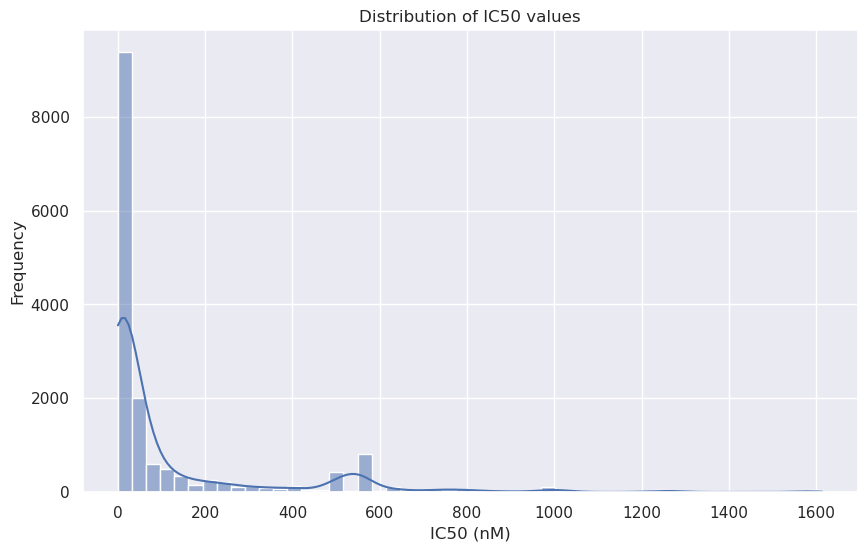

In [62]:
# Convert IC50 column to numeric, forcing errors to NaN
df_selected['IC50 (nM)'] = pd.to_numeric(df_selected['IC50 (nM)'], errors='coerce')

# Drop rows with NaN values in IC50 column
df_selected = df_selected.dropna(subset=['IC50 (nM)'])

# Plot the distribution of IC50 values
plt.figure(figsize=(10, 6))
sns.histplot(df_selected['IC50 (nM)'], bins=50, kde=True)
plt.xlabel('IC50 (nM)')
plt.ylabel('Frequency')
plt.title('Distribution of IC50 values')
plt.show()

In [63]:
df_selected['pIC50'] = -np.log10(df_selected['IC50 (nM)']*1e-9)
df_selected.head()

,SMILES,IC50 (nM),pIC50
0,C#CC(=O)N(C)CCOc1c(N)ncnc1-c1cc(F)cc(NC(=O)c2c...,1.8,8.744727
1,C=CC(=O)N1CCC[C@@H](Nc2nc(Nc3cnn(CCN4CCOCC4)c3...,1.8,8.744727
2,C=CC(=O)N(C)C1CCCN(c2ccc(C(N)=O)c3[nH]c(C)c(C)...,1.8,8.744727
3,C=CC(=O)N1CC[C@]2(C1)C[C@H](n1c(NC(=O)c3cncs3)...,1.8,8.744727
4,CC#CC(=O)N[C@@H](C)c1nc(-c2ccc(C(=O)Nc3cc(C(F)...,1.8,8.744727


In [64]:
df_selected = df_selected.drop(columns=['IC50 (nM)'])
df_selected

,SMILES,pIC50
0,C#CC(=O)N(C)CCOc1c(N)ncnc1-c1cc(F)cc(NC(=O)c2c...,8.744727
1,C=CC(=O)N1CCC[C@@H](Nc2nc(Nc3cnn(CCN4CCOCC4)c3...,8.744727
2,C=CC(=O)N(C)C1CCCN(c2ccc(C(N)=O)c3[nH]c(C)c(C)...,8.744727
3,C=CC(=O)N1CC[C@]2(C1)C[C@H](n1c(NC(=O)c3cncs3)...,8.744727
4,CC#CC(=O)N[C@@H](C)c1nc(-c2ccc(C(=O)Nc3cc(C(F)...,8.744727
...,...,...
20655,CN(C)C/C=C/C(=O)N1CC2(CC(n3nc(-c4ccc(Oc5ccccc5...,8.744727
20656,C=CC(=O)N1CC[C@@H](C)[C@@H](Nc2nc(Nc3cnn(CC#N)...,8.744727
20657,C=CC(=O)N1CCC[C@@H](Nc2nc(Nc3cnoc3)nc3[nH]nc(C...,8.744727
20658,C[C@@H](O)C(=O)N[C@H]1CC[C@@H](Nc2ncnc3[nH]cc(...,8.744727


In [65]:
# We convert SMILES to numerical representation using MACCS keys to be used in Neural Network, use one-hot encoding
# Convert SMILES to MACCS keys

In [66]:
def smiles_to_fp(smiles, method="maccs", n_bits=2048):
    """
    Encode a molecule from a SMILES string into a fingerprint.

    Parameters
    ----------
    smiles : str
        The SMILES string defining the molecule.

    method : str
        The type of fingerprint to use. Default is MACCS keys.

    n_bits : int
        The length of the fingerprint.

    Returns
    -------
    array
        The fingerprint array.
    """

    # Convert smiles to RDKit mol object
    mol = Chem.MolFromSmiles(smiles)

    if method == "maccs":
        return np.array(MACCSkeys.GenMACCSKeys(mol))
    if method == "morgan2":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    if method == "morgan3":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    else:
        print(f"Warning: Wrong method specified: {method}." " Default will be used instead.")
        return np.array(MACCSkeys.GenMACCSKeys(mol))

In [70]:
df_selected["fingerprints_df"] = df_selected["SMILES"].apply(smiles_to_fp)

# Look at head
print("Shape of dataframe:", df_selected.shape)
df_selected.head(3)
# NBVAL_CHECK_OUTPUT

Shape of dataframe: (16171, 3)


,SMILES,pIC50,fingerprints_df
0,C#CC(=O)N(C)CCOc1c(N)ncnc1-c1cc(F)cc(NC(=O)c2c...,8.744727,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,C=CC(=O)N1CCC[C@@H](Nc2nc(Nc3cnn(CCN4CCOCC4)c3...,8.744727,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,C=CC(=O)N(C)C1CCCN(c2ccc(C(N)=O)c3[nH]c(C)c(C)...,8.744727,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


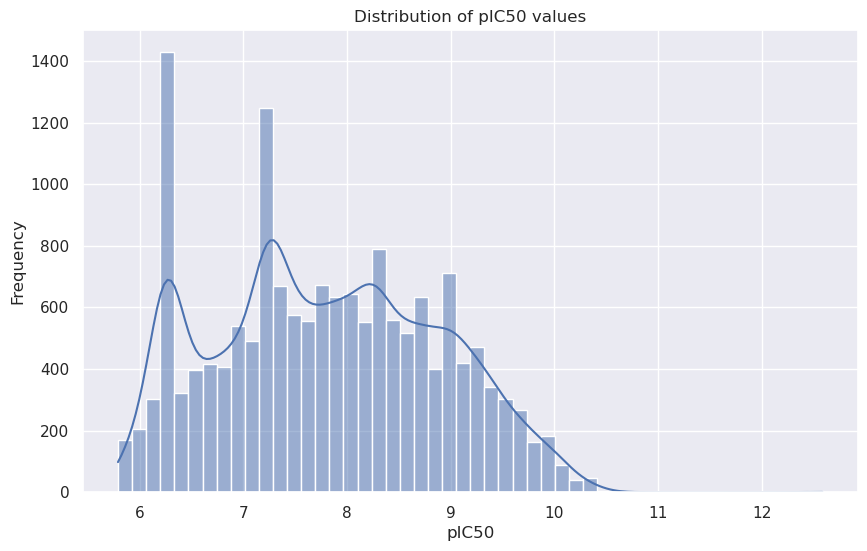

In [71]:
#df_selected.head()  
plt.figure(figsize=(10, 6))
sns.histplot(df_selected['pIC50'], bins=50, kde=True)
plt.xlabel('pIC50')
plt.ylabel('Frequency')
plt.title('Distribution of pIC50 values')
plt.show()

In [72]:
# Split the data into training and test set
x_train, x_test, y_train, y_test = train_test_split(
    df_selected["fingerprints_df"], df_selected[["pIC50"]], test_size=0.3, random_state=42
)

# Print the shape of training and testing data
print("Shape of training data:", x_train.shape)
print("Shape of test data:", x_test.shape)
# NBVAL_CHECK_OUTPUT

Shape of training data: (11319,)
Shape of test data: (4852,)


A keras model is defined by specifying the number of neurons in the hidden layers and the activation function as arguments. For our purpose, we define a model with two hidden layers. We use ReLU in the hidden layers and a linear function on the output layer, since the aim is to predict pIC50 values. Finally, we compile the model using the mean squared error as a loss argument and adam as an optimizer.

In [55]:
# Define neural network

In [73]:
def neural_network_model(hidden1, hidden2):
    """
    Creating a neural network from two hidden layers
    using ReLU as activation function in the two hidden layers
    and a linear activation in the output layer.

    Parameters
    ----------
    hidden1 : int
        Number of neurons in first hidden layer.

    hidden2: int
        Number of neurons in second hidden layer.

    Returns
    -------
    model
        Fully connected neural network model with two hidden layers.
    """

    model = Sequential()
    # First hidden layer
    model.add(Dense(hidden1, activation="relu", name="layer1"))
    # Second hidden layer
    model.add(Dense(hidden2, activation="relu", name="layer2"))
    # Output layer
    model.add(Dense(1, activation="linear", name="layer3"))

    # Compile model
    model.compile(loss="mean_squared_error", optimizer="adam", metrics=["mse", "mae"])
    return model

In [74]:
# Neural network parameters
batch_sizes = [16, 32, 64]
nb_epoch = 50
layer1_size = 64
layer2_size = 32

Epoch 1/50
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.7373 - mae: 1.5270 - mse: 5.7373 - val_loss: 0.8903 - val_mae: 0.7398 - val_mse: 0.8903
Epoch 2/50
708/708 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7724 - mae: 0.7081 - mse: 0.7724 - val_loss: 0.7011 - val_mae: 0.6614 - val_mse: 0.7011
Epoch 3/50
708/708 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7049 - mae: 0.6732 - mse: 0.7049 - val_loss: 0.7277 - val_mae: 0.6940 - val_mse: 0.7277
Epoch 4/50
708/708 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6856 - mae: 0.6643 - mse: 0.6856 - val_loss: 0.6687 - val_mae: 0.6463 - val_mse: 0.6687
Epoch 5/50
708/708 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6427 - mae: 0.6388 - mse: 0.6427 - val_loss: 0.6276 - val_mae: 0.6276 - val_mse: 0.6276
Epoch 6/50
708/708 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6186 - mae: 0.6254 - mse: 0.6186 - val_loss: 0.7305 - val_mae: 0.6623 - val_mse: 0.7305
Epoch 7/50
708/708 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6110 - mae: 0.6215 - mse: 0.6110 - val

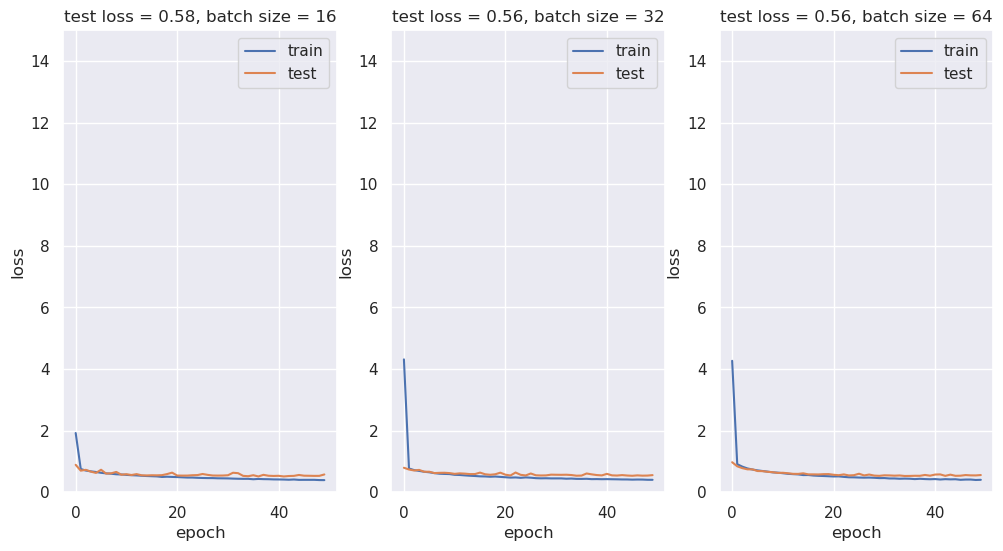

In [75]:
# Plot
fig = plt.figure(figsize=(12, 6))
sns.set(color_codes=True)
for index, batch in enumerate(batch_sizes):
    fig.add_subplot(1, len(batch_sizes), index + 1)
    model = neural_network_model(layer1_size, layer2_size)  # use this for two hidden layers

    # Fit model on x_train, y_train data
    history = model.fit(
        np.array(list(x_train)).astype(float),
        y_train.values,
        batch_size=batch,
        validation_data=(np.array(list(x_test)).astype(float), y_test.values),
        verbose=1,
        epochs=nb_epoch,
    )
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="test")
    plt.legend(["train", "test"], loc="upper right")
    plt.ylabel("loss")
    plt.xlabel("epoch")
    plt.ylim((0, 15))
    plt.title(
        f"test loss = {history.history['val_loss'][nb_epoch-1]:.2f}, " f"batch size = {batch}"
    )
plt.show()

In [76]:
# Save the trained model
filepath = DATA / "data/best_weights.weights.h5"
checkpoint = ModelCheckpoint(
    str(filepath),
    monitor="loss",
    verbose=0,
    save_best_only=True,
    mode="min",
    save_weights_only=True,
)
callbacks_list = [checkpoint]

# Fit the model
model.fit(
    np.array(list((x_train))).astype(float),
    y_train.values,
    epochs=nb_epoch,
    batch_size=32,
    callbacks=callbacks_list,
    verbose=0,
)

In [77]:
# Evalute the model
print(f"Evaluate the model on the test data")
scores = model.evaluate(np.array(list((x_test))), y_test.values, verbose=0)
print(f" loss: {scores[0]:.2f}")
print(f" mse (same as loss): {scores[1]:.2f}")
print(f" mae: {scores[2]:.2f}")

Evaluate the model on the test data
 loss: 0.59
 mse (same as loss): 0.59
 mae: 0.59


In [78]:
# Predict pIC50 values on x_test data
y_pred = model.predict(np.array(list((x_test))))

# Print 5 first pIC50 predicted values
first_5_prediction = [print(f"{value[0]:.2f}") for value in y_pred[0:5]]

152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step
8.49
6.31
5.44
9.42
6.86


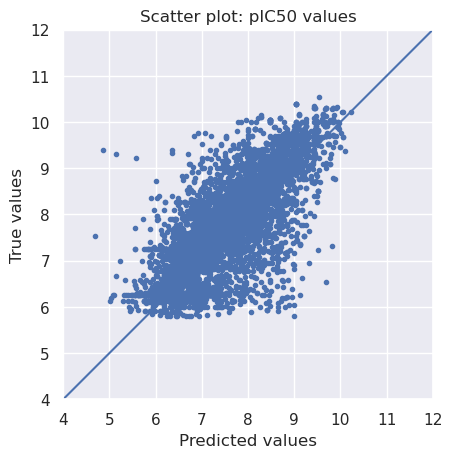

In [79]:
# Scatter plot
limits = 4, 12
fig, ax = plt.subplots()
ax.scatter(y_pred, y_test, marker=".")
lin = np.linspace(*limits, 100)
ax.plot(lin, lin)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Predicted values")
ax.set_ylabel("True values")
ax.set_title("Scatter plot: pIC50 values")
ax.set_xlim(limits)
ax.set_ylim(limits)
plt.show()

In [80]:
from sklearn.metrics import r2_score

# Calculate R-squared
r_squared = r2_score(y_test, y_pred)

# Print R-squared value
print(f"R-squared: {r_squared:.2f}")

R-squared: 0.48


In [83]:
df_external = PandasTools.LoadSDF(DATA / "data/btk_fenebrutinib_analogs.sdf")
df_external.head()

,ID,ROMol
0,btk_fenebrutinib_analogs.sdf,<rdkit.Chem.rdchem.Mol object at 0x7aef229fadd0>
1,btk_fenebrutinib_analogs.sdf,<rdkit.Chem.rdchem.Mol object at 0x7aef229faeb0>
2,btk_fenebrutinib_analogs.sdf,<rdkit.Chem.rdchem.Mol object at 0x7aef229fa970>
3,btk_fenebrutinib_analogs.sdf,<rdkit.Chem.rdchem.Mol object at 0x7aef229faa50>
4,btk_fenebrutinib_analogs.sdf,<rdkit.Chem.rdchem.Mol object at 0x7aef229faac0>


In [84]:
# Convert RDKit ROMol to SMILES
df_external['SMILES'] = df_external['ROMol'].apply(Chem.MolToSmiles)

# Select the SMILES column
smiles_column = df_external[['SMILES']]

# Save the SMILES column to a CSV file
smiles_column.to_csv(DATA / 'btk_smiles_external.csv', index=False)

In [85]:
# Load external/unlabeled data set
#external_data = external_data.reset_index(drop=True)
#external_data.head()
# NBVAL_CHECK_OUTPUT

In [86]:
# Load external/unlabeled data set
external_data = pd.read_csv(DATA / "btk_smiles_external.csv")
external_data["fingerprints_df"] = external_data['SMILES'].apply(smiles_to_fp)

# Look at head
print("Shape of dataframe : ", external_data.shape)
external_data.head(3)
# NBVAL_CHECK_OUTPUT

Shape of dataframe :  (6, 2)


,SMILES,fingerprints_df
0,C[C@H]1CN(C2COC2)CCN1c1ccc(Nc2cc(-c3ccnc(N4CCn...,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, ..."
1,CCN(CC)C1CCN(c2ccc(Nc3cc(-c4ccnc(N5CCn6c(cc7c6...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,C[C@@H]1CN(c2ccc(Nc3cc(-c4ccnc(N5CCn6c(cc7c6CC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [87]:
# Define the model architecture
#model = neural_network_model(layer1_size, layer2_size)

# Build the model by calling it on some data
#model.build(input_shape=(None, len(x_train.iloc[0])))

# Load the model weights
model.load_weights(DATA / "data/best_weights.weights.h5")

In [88]:
# Prediction on external/unlabeled data
predictions = model.predict(
    np.array(list((external_data["fingerprints_df"]))).astype(float), callbacks=callbacks_list
)

predicted_pIC50 = pd.DataFrame(predictions, columns=["predicted_pIC50"])
predicted_pIC50_df = external_data.join(predicted_pIC50)

predicted_pIC50_df.head(3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


,SMILES,fingerprints_df,predicted_pIC50
0,C[C@H]1CN(C2COC2)CCN1c1ccc(Nc2cc(-c3ccnc(N4CCn...,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, ...",7.818463
1,CCN(CC)C1CCN(c2ccc(Nc3cc(-c4ccnc(N5CCn6c(cc7c6...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",8.029102
2,C[C@@H]1CN(c2ccc(Nc3cc(-c4ccnc(N5CCn6c(cc7c6CC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",8.008129


In [89]:
# Save the predicted values in a csv file in the data folder
predicted_pIC50_df.to_csv(DATA / "predicted_pIC50_df.csv")

In [90]:
# Select top 3 drugs
predicted_pIC50_df = pd.read_csv(DATA / "predicted_pIC50_df.csv", index_col=0)
top3_drug = predicted_pIC50_df.nlargest(20, "predicted_pIC50")
top3_drug

,SMILES,fingerprints_df,predicted_pIC50
3,C[C@H]1CN(c2cnn(C)c2)CCN1c1ccc(Nc2cc(-c3ccnc(N...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,8.034323
1,CCN(CC)C1CCN(c2ccc(Nc3cc(-c4ccnc(N5CCn6c(cc7c6...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,8.029102
2,C[C@@H]1CN(c2ccc(Nc3cc(-c4ccnc(N5CCn6c(cc7c6CC...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,8.008129
0,C[C@H]1CN(C2COC2)CCN1c1ccc(Nc2cc(-c3ccnc(N4CCn...,[0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0...,7.818463
4,C[C@H]1CN(C2=C3C=CC=CC3NC2)CCN1c1ccc(Nc2cc(-c3...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,7.779609
5,C[C@H]1CN(c2ccccc2)CCN1c1ccc(Nc2cc(-c3ccnc(N4C...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,7.693008


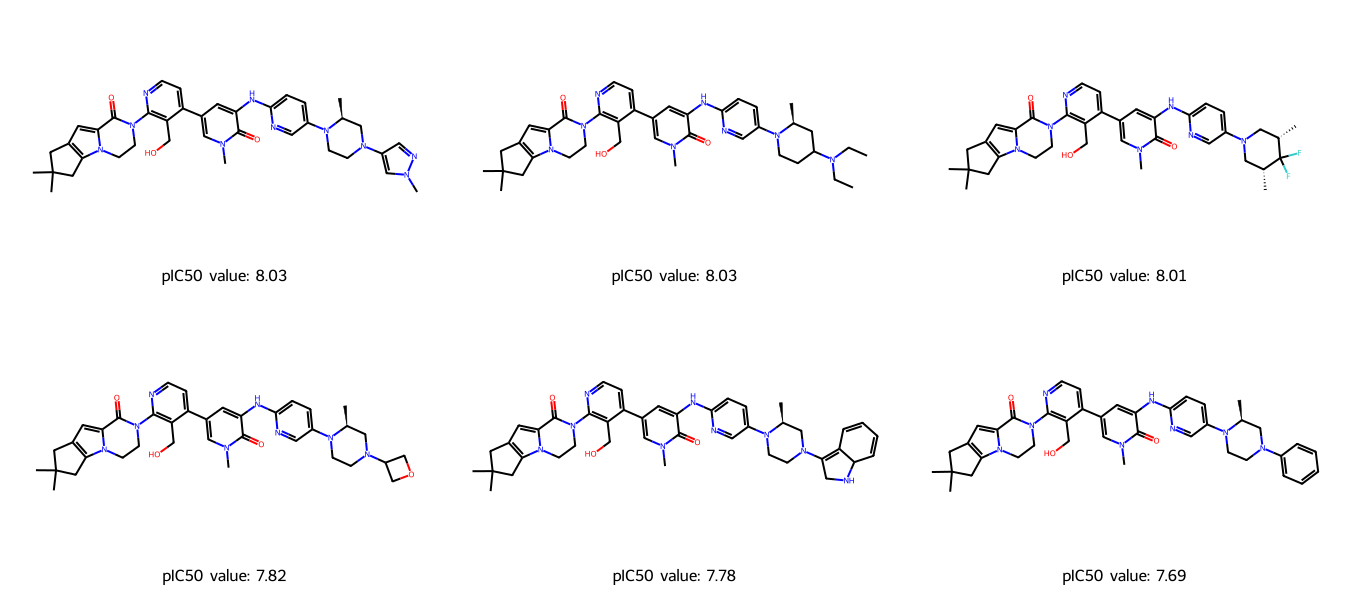

In [91]:
# Draw the drug molecules
highest_pIC50 = predicted_pIC50_df["SMILES"][top3_drug.index]

mols_EGFR = [Chem.MolFromSmiles(smile) for smile in highest_pIC50]
pIC50_EGFR = top3_drug["predicted_pIC50"].tolist()
pIC50_values = [(f"pIC50 value: {value:.2f}") for value in pIC50_EGFR]

Draw.MolsToGridImage(mols_EGFR, molsPerRow=3, subImgSize=(450, 300), legends=pIC50_values)

In [92]:
# Convert pIC50 to IC50 (nM)
predicted_pIC50_df['IC50 (nM)'] = 10**(9 - predicted_pIC50_df['predicted_pIC50'])
predicted_pIC50_df

,SMILES,fingerprints_df,predicted_pIC50,IC50 (nM)
0,C[C@H]1CN(C2COC2)CCN1c1ccc(Nc2cc(-c3ccnc(N4CCn...,[0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0...,7.818463,15.189263
1,CCN(CC)C1CCN(c2ccc(Nc3cc(-c4ccnc(N5CCn6c(cc7c6...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,8.029102,9.351860
2,C[C@@H]1CN(c2ccc(Nc3cc(-c4ccnc(N5CCn6c(cc7c6CC...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,8.008129,9.814564
3,C[C@H]1CN(c2cnn(C)c2)CCN1c1ccc(Nc2cc(-c3ccnc(N...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,8.034323,9.240107
4,C[C@H]1CN(C2=C3C=CC=CC3NC2)CCN1c1ccc(Nc2cc(-c3...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,7.779609,16.610829
5,C[C@H]1CN(c2ccccc2)CCN1c1ccc(Nc2cc(-c3ccnc(N4C...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,7.693008,20.276454


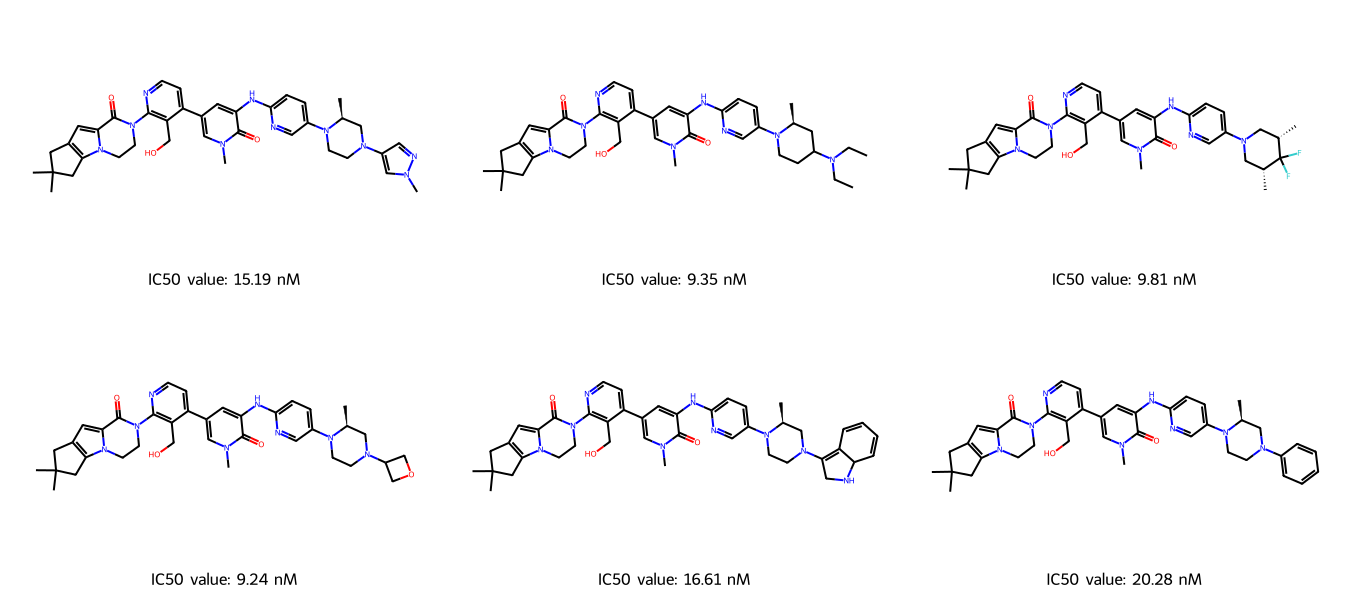

In [93]:
# Draw the drug molecules with IC50 values in nM
ic50_values = predicted_pIC50_df["IC50 (nM)"].tolist()
legends = [f"IC50 value: {value:.2f} nM" for value in ic50_values]

Draw.MolsToGridImage(mols_EGFR, molsPerRow=3, subImgSize=(450, 300), legends=legends)

In [94]:
predicted_pIC50_df.to_csv(DATA / "predicted_pIC50_df.csv")